Algorithms to fit Gaussian
==========================

In [1]:
import numpy as np
import pandas as pd
import h5py
import torch

import matplotlib.pyplot as plt

In [2]:
sim_output_path = '/Users/yuntse/data/lartpc_rd/gampix/detsim/radiologicals/gampixpy_fullgeoanatruth-vd-reduced_g4_00_2Mhz_segmentlabel_lowtrig_5mmpitch.h5'

In [3]:
# GAMPixPy outputs
with h5py.File(sim_output_path, 'r') as simf:
    # Print all top-level groups/datasets
    print(list(simf.keys()))
    fT = simf['tiles']
    # fP = simf['pixels']
    # fM = simf['meta']
    print(fT.dtype)
    # print(fP.dtype)
    # print(fM.dtype)

    tempT = fT[()]
    # tempP = fP[()]
    # tempM = fM[()]

['meta', 'pixels', 'tiles']
[('event id', '<u4'), ('tile tpc', '<u4'), ('tile x', '<f4'), ('tile y', '<f4'), ('trig z', '<f4'), ('trig t', '<f4'), ('waveform', '<f4', (20,)), ('attribution', '<f4', (20, 3)), ('label', '<i4', (3,))]


In [4]:
dT = pd.DataFrame({
    name: tempT[name].tolist() if tempT[name].ndim > 1 else tempT[name]
    for name in tempT.dtype.names
})
dT

,event id,tile tpc,tile x,tile y,trig z,trig t,waveform,attribution,label
0,0,0,-1065.0,-575.0,929.386963,5804.554199,"[71.76718139648438, 62.810279846191406, 113.80...","[[0.48086702823638916, 0.5191329121589661, 0.0...","[8158, 8157, -9999]"
1,0,0,-1065.0,-545.0,1020.091187,6371.054199,"[-32.999149322509766, -88.00483703613281, 9.21...","[[1.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8102, -9999, -9999]"
2,0,0,-1065.0,-535.0,1021.131958,6377.554199,"[-34.37238311767578, 84.75414276123047, 24.533...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8100, 8099, -9999]"
3,0,0,-1055.0,-575.0,-568.794189,-3552.445801,"[94.542724609375, 43.767486572265625, -48.5439...","[[0.0, 1.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, ...","[7192, 7191, 5816]"
4,0,0,-1055.0,-575.0,-506.269928,-3161.945801,"[44.93190002441406, 221.96304321289062, 4.0670...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, ...","[5814, 7192, 7191]"
...,...,...,...,...,...,...,...,...,...
1093436,999,0,-735.0,-475.0,-491.921753,-3072.333252,"[96.73655700683594, -19.9937686920166, -91.338...","[[0.0, 1.0, 0.0], [0.0, 1.0, 0.0], [1.0, 0.0, ...","[8828759, 8828758, -9999]"
1093437,999,0,-735.0,-365.0,356.679321,2227.666748,"[586.3011474609375, 369.4231872558594, -61.994...","[[0.9081302881240845, 0.0, 0.09186971187591553...","[8830264, 8830266, 8830263]"
1093438,999,0,-735.0,-355.0,381.176666,2380.666748,"[40.48929977416992, 7.63347053527832, 121.1170...","[[0.0, 1.0, 0.0], [0.0, 0.0, 0.0], [0.24980983...","[8833149, 8833150, 8833151]"
1093439,999,0,-735.0,-355.0,385.179504,2405.666748,"[57.617530822753906, 137.14410400390625, 11.58...","[[0.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 1.0, ...","[8833145, 8833143, 8833146]"


In [5]:
dT['charge'] = dT['waveform'].apply(sum)

In [6]:
dT2 = dT.head(10000).copy()

## Default fit: fit a Gaussian + baseline

In [7]:
def torch_gaussian_fit(
    df,
    col = "values",
    batch_size = 50000,
    n_steps = 300,
    lr = 0.05,
    device = None
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    Y_all = np.stack(df[col].to_numpy()).astype(np.float32)
    N, M = Y_all.shape
    dtick = 0.5
    x = (torch.arange(M, dtype = torch.float32, device = device) * dtick)[None, :]  # shape (1, M)

    amp_all = np.empty(N, dtype = np.float32)
    mu_all = np.empty(N, dtype = np.float32)
    sigma_all = np.empty(N, dtype = np.float32)
    offset_all = np.empty(N, dtype = np.float32)
    rmse_all = np.empty(N, dtype = np.float32)

    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        Y_np = Y_all[start:end]
        Y = torch.tensor(Y_np, device = device)

        # initialization from moments
        offset0 = Y.min(dim = 1).values
        Y0 = torch.clamp(Y - offset0[:, None], min=0.0)
        wsum = Y0.sum(dim = 1)

        valid = wsum > 1e-8

        amp0 = Y0.max(dim = 1).values
        mu0 = torch.zeros_like(offset0)
        sigma0 = torch.ones_like(offset0) * 2.0

        if valid.any():
            mu0[valid] = (Y0[valid] * x).sum(dim = 1) / wsum[valid]
            var0 = (Y0[valid] * (x - mu0[valid, None]) ** 2).sum(dim = 1) / wsum[valid]
            sigma0[valid] = torch.sqrt(torch.clamp(var0, min = 1e-6))

        # unconstrained parameters for stable optimization
        log_amp = torch.log(torch.clamp(amp0, min = 1e-6)).detach().clone().requires_grad_(True)
        mu = mu0.detach().clone().requires_grad_(True)
        log_sigma = torch.log(torch.clamp(sigma0, min = 1e-6)).detach().clone().requires_grad_(True)
        offset = offset0.detach().clone().requires_grad_(True)

        optimizer = torch.optim.Adam([log_amp, mu, log_sigma, offset], lr = lr)

        for _ in range(n_steps):
            optimizer.zero_grad()

            amp = torch.exp(log_amp)[:, None]
            sigma = torch.exp(log_sigma)[:, None]
            mu_b = mu[:, None]
            offset_b = offset[:, None]

            Yhat = amp * torch.exp(-0.5 * ((x - mu_b) / sigma) ** 2) + offset_b
            loss = ((Yhat - Y) ** 2).mean()

            loss.backward()
            optimizer.step()

            # optional mild constraints
            with torch.no_grad():
                mu.clamp_(0.0, M - 1.0)

        with torch.no_grad():
            amp_f = torch.exp(log_amp)
            sigma_f = torch.exp(log_sigma)
            Yhat = amp_f[:, None] * torch.exp(-0.5 * ((x - mu[:, None]) / sigma_f[:, None]) ** 2) + offset[:, None]
            rmse = torch.sqrt(((Yhat - Y) ** 2).mean(dim = 1))

            amp_all[start:end] = amp_f.cpu().numpy()
            mu_all[start:end] = mu.cpu().numpy()
            sigma_all[start:end] = sigma_f.cpu().numpy()
            offset_all[start:end] = offset.cpu().numpy()
            rmse_all[start:end] = rmse.cpu().numpy()

        print(f"Processed rows {start:,} to {end:,} / {N:,}")

    result = pd.DataFrame({
        "amp": amp_all,
        "mu": mu_all,
        "sigma": sigma_all,
        "offset": offset_all,
        "rmse": rmse_all,
    }, index = df.index)

    return result

In [8]:
fit_torch = torch_gaussian_fit(
    dT,
    col = "waveform",
    batch_size = 20000,   # tune based on GPU memory
    n_steps = 200,
    lr = 0.03
)

dT = pd.concat([dT, fit_torch.add_prefix("fit_offset_")], axis = 1)

Processed rows 0 to 20,000 / 1,093,441
Processed rows 20,000 to 40,000 / 1,093,441
Processed rows 40,000 to 60,000 / 1,093,441
Processed rows 60,000 to 80,000 / 1,093,441
Processed rows 80,000 to 100,000 / 1,093,441
Processed rows 100,000 to 120,000 / 1,093,441
Processed rows 120,000 to 140,000 / 1,093,441
Processed rows 140,000 to 160,000 / 1,093,441
Processed rows 160,000 to 180,000 / 1,093,441
Processed rows 180,000 to 200,000 / 1,093,441
Processed rows 200,000 to 220,000 / 1,093,441
Processed rows 220,000 to 240,000 / 1,093,441
Processed rows 240,000 to 260,000 / 1,093,441
Processed rows 260,000 to 280,000 / 1,093,441
Processed rows 280,000 to 300,000 / 1,093,441
Processed rows 300,000 to 320,000 / 1,093,441
Processed rows 320,000 to 340,000 / 1,093,441
Processed rows 340,000 to 360,000 / 1,093,441
Processed rows 360,000 to 380,000 / 1,093,441
Processed rows 380,000 to 400,000 / 1,093,441
Processed rows 400,000 to 420,000 / 1,093,441
Processed rows 420,000 to 440,000 / 1,093,441
Pr

In [9]:
dT

,event id,tile tpc,tile x,tile y,trig z,trig t,waveform,attribution,label,charge,fit_offset_amp,fit_offset_mu,fit_offset_sigma,fit_offset_offset,fit_offset_rmse
0,0,0,-1065.0,-575.0,929.386963,5804.554199,"[71.76718139648438, 62.810279846191406, 113.80...","[[0.48086702823638916, 0.5191329121589661, 0.0...","[8158, 8157, -9999]",1386.506609,183.697647,3.686307,4.160139,-75.399185,57.995762
1,0,0,-1065.0,-545.0,1020.091187,6371.054199,"[-32.999149322509766, -88.00483703613281, 9.21...","[[1.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8102, -9999, -9999]",304.031366,136.001678,5.852718,3.900318,-88.640022,40.152386
2,0,0,-1065.0,-535.0,1021.131958,6377.554199,"[-34.37238311767578, 84.75414276123047, 24.533...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8100, 8099, -9999]",966.326665,198.740662,3.467906,2.800527,-80.960854,52.312153
3,0,0,-1055.0,-575.0,-568.794189,-3552.445801,"[94.542724609375, 43.767486572265625, -48.5439...","[[0.0, 1.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, ...","[7192, 7191, 5816]",480.919051,113.308533,4.373268,5.580275,-75.706703,61.486629
4,0,0,-1055.0,-575.0,-506.269928,-3161.945801,"[44.93190002441406, 221.96304321289062, 4.0670...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, ...","[5814, 7192, 7191]",126.962569,126.963753,1.227697,5.365709,-88.862137,58.000916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1093436,999,0,-735.0,-475.0,-491.921753,-3072.333252,"[96.73655700683594, -19.9937686920166, -91.338...","[[0.0, 1.0, 0.0], [0.0, 1.0, 0.0], [1.0, 0.0, ...","[8828759, 8828758, -9999]",344.125580,140.526474,2.075865,4.920420,-91.326569,64.913322
1093437,999,0,-735.0,-365.0,356.679321,2227.666748,"[586.3011474609375, 369.4231872558594, -61.994...","[[0.9081302881240845, 0.0, 0.09186971187591553...","[8830264, 8830266, 8830263]",1105.921688,278.443390,0.580201,4.806057,-130.776550,135.897263
1093438,999,0,-735.0,-355.0,381.176666,2380.666748,"[40.48929977416992, 7.63347053527832, 121.1170...","[[0.0, 1.0, 0.0], [0.0, 0.0, 0.0], [0.24980983...","[8833149, 8833150, 8833151]",34607.093809,4656.823242,5.653616,1.455936,11.842931,125.253441
1093439,999,0,-735.0,-355.0,385.179504,2405.666748,"[57.617530822753906, 137.14410400390625, 11.58...","[[0.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 1.0, ...","[8833145, 8833143, 8833146]",424.614502,77.999527,6.095194,12.736507,-54.560341,53.127354


In [10]:
def gauss(x, a, mu, sigma, c):
    return a * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + c

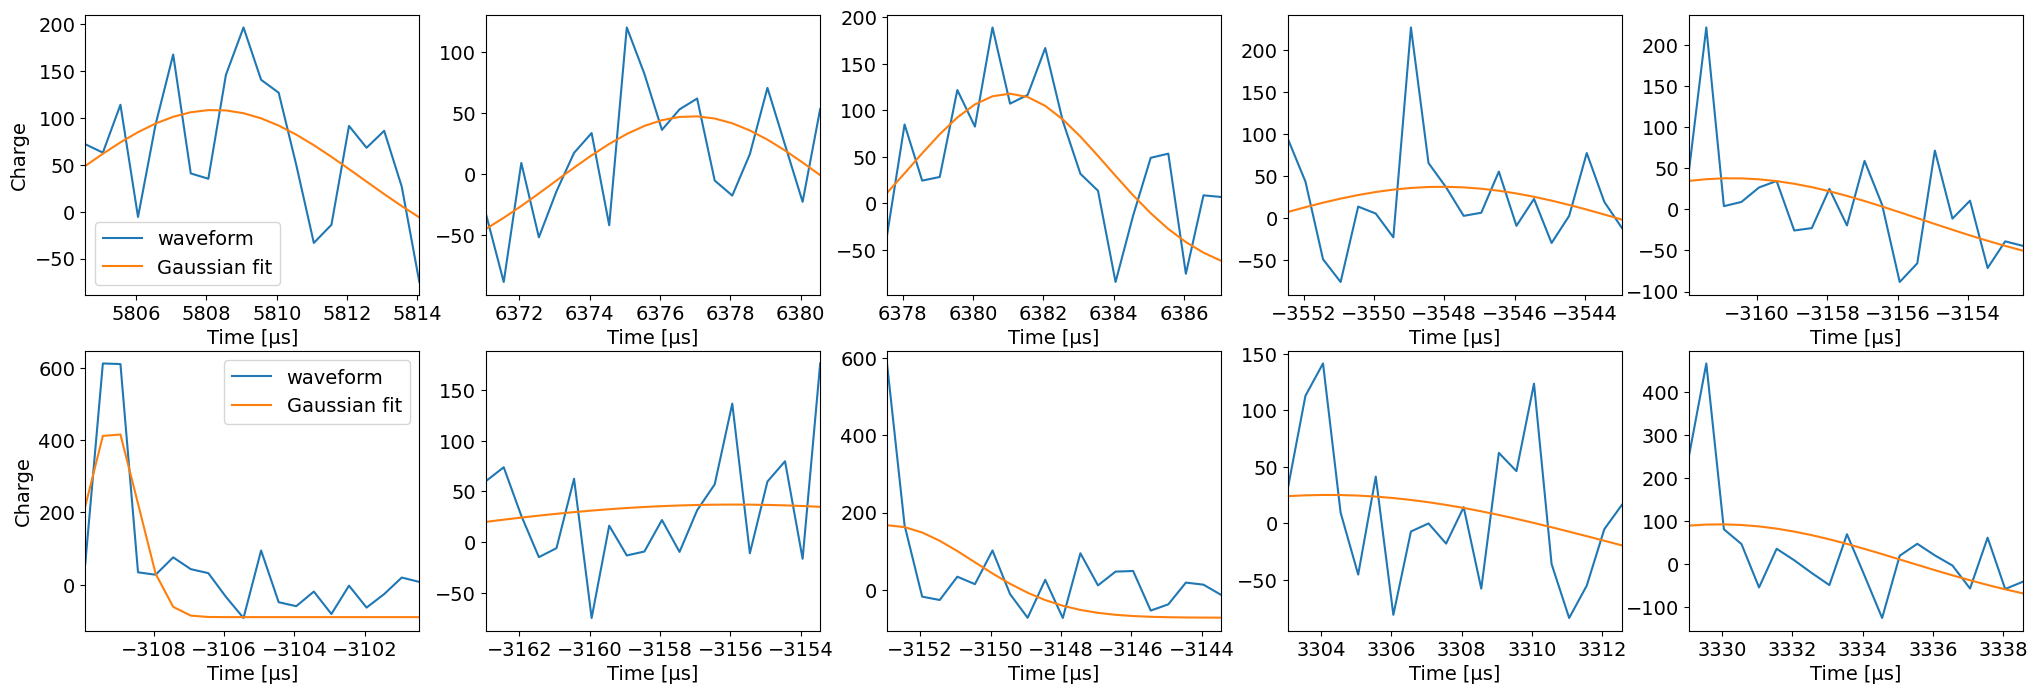

In [11]:
fig, ax = plt.subplots(2, 5, figsize = (25, 8))

dtick = 0.5
t = np.arange(20) * dtick
fonts = 14

for i in range(2):
    for j in range(5):
        k = 5*i + j
        ax[i][j].plot(t + dT.loc[k, "trig t"], dT.loc[k, "waveform"], label = 'waveform')
        y = gauss(t, a = dT.loc[k, "fit_offset_amp"], mu = dT.loc[k, "fit_offset_mu"], sigma = dT.loc[k, "fit_offset_sigma"], c = dT.loc[k, "fit_offset_offset"])
        ax[i][j].plot(t + dT.loc[k, "trig t"], y, label = 'Gaussian fit')

        ax[i][j].set_xlabel('Time [µs]', fontsize = fonts)
        ax[i][j].tick_params(axis = "both", labelsize = fonts)
        ax[i][j].set_xlim([dT.loc[k, "trig t"], dT.loc[k, "trig t"]+9.5])

    ax[i][0].set_ylabel('Charge', fontsize = fonts)
    ax[i][0].legend(fontsize = fonts)


In [12]:
dT['fit_offset_charge'] = dT['fit_offset_amp']*dT['fit_offset_sigma']*np.sqrt(2*np.pi)

In [14]:
dT['fit_offset_rel_diff'] = (dT['fit_offset_charge']-0.5*dT['charge'])*2/dT['charge']
dT['fit_offset_rel_diff'].min(), dT['fit_offset_rel_diff'].max()

(-657817.096487767, 3086853.351489814)

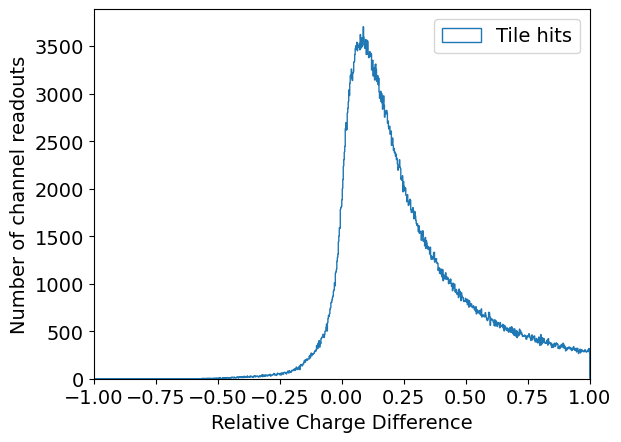

In [24]:
fig, ax = plt.subplots()

tBins = np.linspace(-1, 1, 1001)
fonts = 14

ax.hist(dT['fit_offset_rel_diff'], bins = tBins, histtype = 'step', label = 'Tile hits')
# ax.set_yscale('log')
ax.set_xlim([-1, 1])

ax.set_xlabel('Relative Charge Difference', fontsize = fonts)
ax.set_ylabel('Number of channel readouts', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(fontsize = fonts)

In [ ]:
noise = 50
err_sum = np.sqrt(20*noise)

In [27]:
dT['fit_offset_pull'] = (dT['fit_offset_charge']-0.5*dT['charge'])/err_sum
dT['fit_offset_pull'].min(), dT['fit_offset_pull'].max()

(-461.6406516912388, 2381.7209286731454)

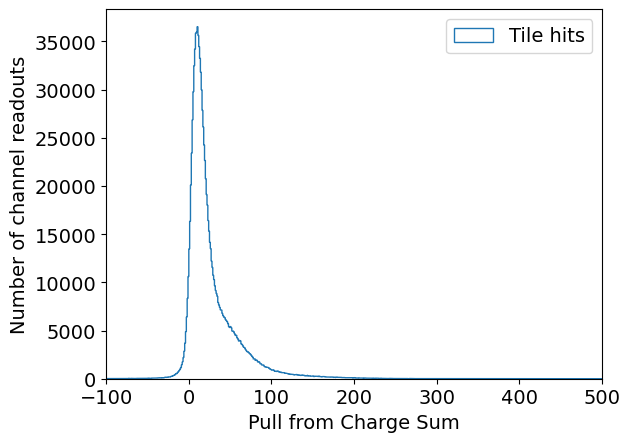

In [30]:
fig, ax = plt.subplots()

tBins = np.linspace(-100, 500, 601)
fonts = 14

ax.hist(dT['fit_offset_pull'], bins = tBins, histtype = 'step', label = 'Tile hits')
# ax.set_yscale('log')
ax.set_xlim([-100, 500])

ax.set_xlabel('Pull from Charge Sum', fontsize = fonts)
ax.set_ylabel('Number of channel readouts', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(fontsize = fonts)

## Fit Gaussian with a fixed baseline

In [16]:
def torch_gaussian_fit_no_offset(
    df,
    col = "values",
    batch_size = 50000,
    n_steps = 300,
    lr = 0.05,
    device = None,
    x_spacing = 0.5
):
    """
    Batch Gaussian fitting on GPU/CPU using PyTorch, without an offset term.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing a column of lists/arrays of equal length.
    col : str
        Column name containing the y-values.
    batch_size : int
        Number of rows to fit per batch.
    n_steps : int
        Number of optimization steps per batch.
    lr : float
        Learning rate for Adam.
    device : str or None
        "cuda", "cpu", or None to auto-detect.
    x_spacing : float
        Spacing between x-points. For 20 points and x_spacing=0.5,
        x = [0.0, 0.5, ..., 9.5]

    Returns
    -------
    pandas.DataFrame
        Columns: amp, mu, sigma, rmse
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # Shape: (N, M)
    Y_all = np.stack(df[col].to_numpy()).astype(np.float32)
    N, M = Y_all.shape

    # x-grid
    x = (torch.arange(M, dtype = torch.float32, device = device) * x_spacing)[None, :]
    x_max = float((M - 1) * x_spacing)

    amp_all = np.empty(N, dtype = np.float32)
    mu_all = np.empty(N, dtype = np.float32)
    sigma_all = np.empty(N, dtype = np.float32)
    rmse_all = np.empty(N, dtype = np.float32)

    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        Y_np = Y_all[start:end]
        Y = torch.tensor(Y_np, device = device)   # shape (B, M)

        # ----------------------------
        # Initialization
        # ----------------------------
        # If no offset is fitted, assume y >= 0 is ideal.
        # Clamp negatives for moment initialization only.
        Y0 = torch.clamp(Y, min = 0.0)
        wsum = Y0.sum(dim = 1)

        valid = wsum > 1e-8

        amp0 = Y0.max(dim = 1).values
        mu0 = torch.full((Y.shape[0],), x_max / 2, device = device)
        sigma0 = torch.full((Y.shape[0],), max(x_spacing * 2, 1e-3), device = device)

        if valid.any():
            mu0[valid] = (Y0[valid] * x).sum(dim = 1) / wsum[valid]
            var0 = (Y0[valid] * (x - mu0[valid, None]) ** 2).sum(dim = 1) / wsum[valid]
            sigma0[valid] = torch.sqrt(torch.clamp(var0, min = 1e-6))

        amp0 = torch.clamp(amp0, min = 1e-6)
        sigma0 = torch.clamp(sigma0, min = 1e-6)

        # Optimize in unconstrained space for amp and sigma
        log_amp = torch.log(amp0).detach().clone().requires_grad_(True)
        mu = mu0.detach().clone().requires_grad_(True)
        log_sigma = torch.log(sigma0).detach().clone().requires_grad_(True)

        optimizer = torch.optim.Adam([log_amp, mu, log_sigma], lr = lr)

        # ----------------------------
        # Optimization
        # ----------------------------
        for _ in range(n_steps):
            optimizer.zero_grad()

            amp = torch.exp(log_amp)[:, None]        # shape (B, 1)
            sigma = torch.exp(log_sigma)[:, None]    # shape (B, 1)
            mu_b = mu[:, None]                       # shape (B, 1)

            Yhat = amp * torch.exp(-0.5 * ((x - mu_b) / sigma) ** 2)
            loss = ((Yhat - Y) ** 2).mean()

            loss.backward()
            optimizer.step()

            # keep mu in x-range
            with torch.no_grad():
                mu.clamp_(0.0, x_max)

        # ----------------------------
        # Save results
        # ----------------------------
        with torch.no_grad():
            amp_f = torch.exp(log_amp)
            sigma_f = torch.exp(log_sigma)

            Yhat = amp_f[:, None] * torch.exp(-0.5 * ((x - mu[:, None]) / sigma_f[:, None]) ** 2)
            rmse = torch.sqrt(((Yhat - Y) ** 2).mean(dim = 1))

            amp_all[start:end] = amp_f.cpu().numpy()
            mu_all[start:end] = mu.cpu().numpy()
            sigma_all[start:end] = sigma_f.cpu().numpy()
            rmse_all[start:end] = rmse.cpu().numpy()

        print(f"Processed rows {start:,} to {end:,} / {N:,}")

    result = pd.DataFrame({
        "amp": amp_all,
        "mu": mu_all,
        "sigma": sigma_all,
        "rmse": rmse_all,
    }, index = df.index)

    return result

In [17]:
fit_torch = torch_gaussian_fit_no_offset(
    df = dT,
    col = "waveform",
    batch_size = 20000,
    n_steps = 200,
    lr = 0.03,
    x_spacing = 0.5
)

dT = pd.concat([dT, fit_torch.add_prefix("fit_")], axis = 1)

Processed rows 0 to 20,000 / 1,093,441
Processed rows 20,000 to 40,000 / 1,093,441
Processed rows 40,000 to 60,000 / 1,093,441
Processed rows 60,000 to 80,000 / 1,093,441
Processed rows 80,000 to 100,000 / 1,093,441
Processed rows 100,000 to 120,000 / 1,093,441
Processed rows 120,000 to 140,000 / 1,093,441
Processed rows 140,000 to 160,000 / 1,093,441
Processed rows 160,000 to 180,000 / 1,093,441
Processed rows 180,000 to 200,000 / 1,093,441
Processed rows 200,000 to 220,000 / 1,093,441
Processed rows 220,000 to 240,000 / 1,093,441
Processed rows 240,000 to 260,000 / 1,093,441
Processed rows 260,000 to 280,000 / 1,093,441
Processed rows 280,000 to 300,000 / 1,093,441
Processed rows 300,000 to 320,000 / 1,093,441
Processed rows 320,000 to 340,000 / 1,093,441
Processed rows 340,000 to 360,000 / 1,093,441
Processed rows 360,000 to 380,000 / 1,093,441
Processed rows 380,000 to 400,000 / 1,093,441
Processed rows 400,000 to 420,000 / 1,093,441
Processed rows 420,000 to 440,000 / 1,093,441
Pr

In [18]:
def gauss_no_offset(x, a, mu, sigma):
    return a * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

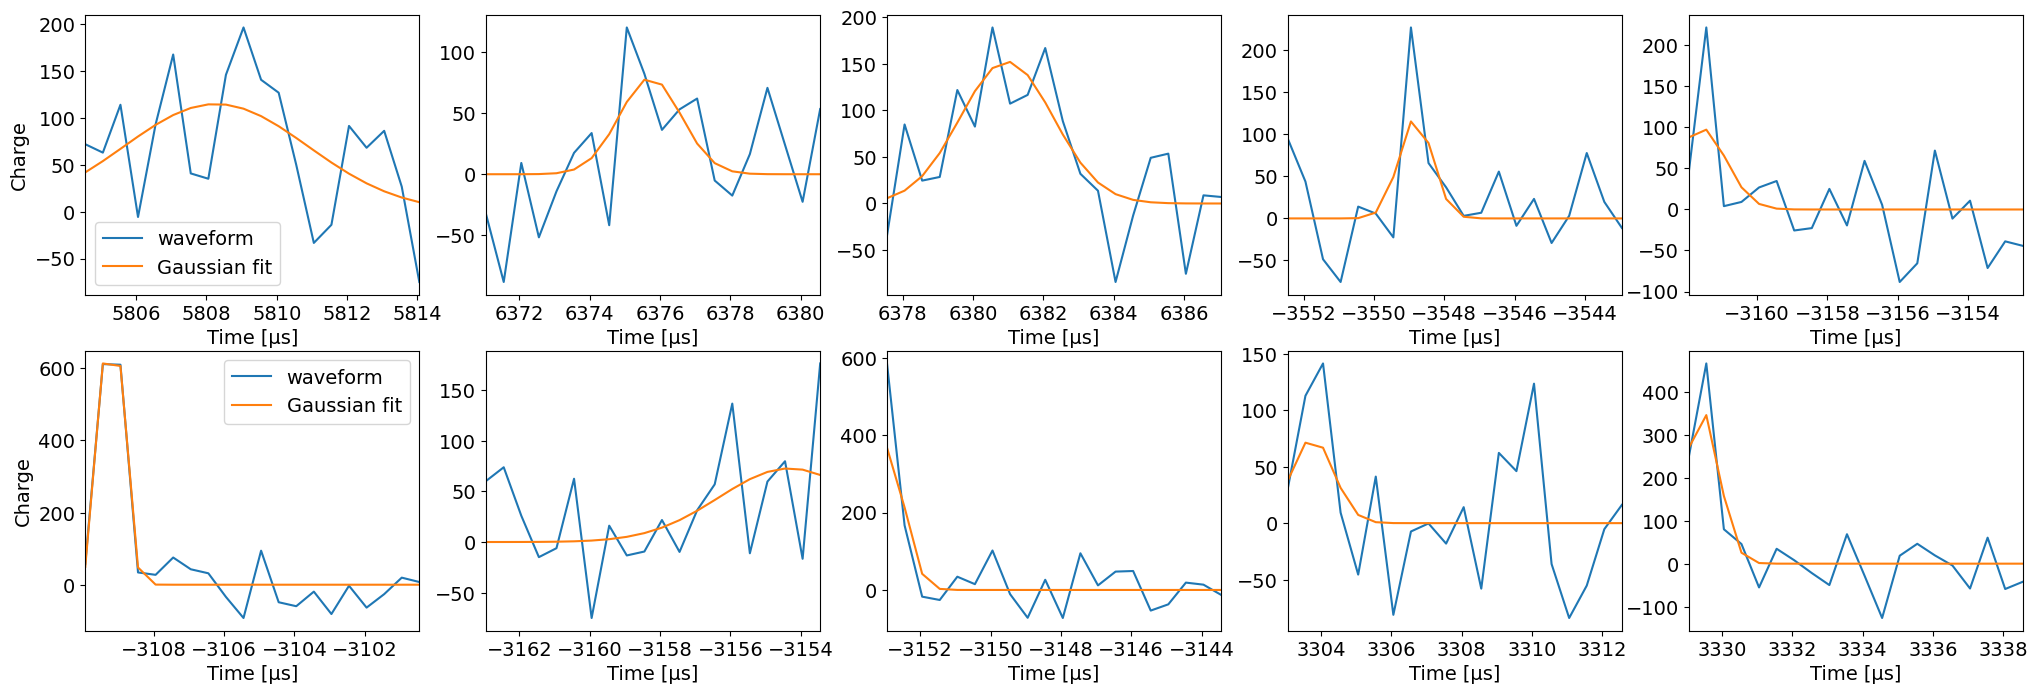

In [19]:
fig, ax = plt.subplots(2, 5, figsize = (25, 8))

dtick = 0.5
t = np.arange(20) * dtick
fonts = 14

for i in range(2):
    for j in range(5):
        k = 5*i + j
        ax[i][j].plot(t + dT.loc[k, "trig t"], dT.loc[k, "waveform"], label = 'waveform')
        y = gauss_no_offset(t, a = dT.loc[k, "fit_amp"], mu = dT.loc[k, "fit_mu"], sigma = dT.loc[k, "fit_sigma"])
        ax[i][j].plot(t + dT.loc[k, "trig t"], y, label = 'Gaussian fit')

        ax[i][j].set_xlabel('Time [µs]', fontsize = fonts)
        ax[i][j].tick_params(axis = "both", labelsize = fonts)
        ax[i][j].set_xlim([dT.loc[k, "trig t"], dT.loc[k, "trig t"]+9.5])

    ax[i][0].set_ylabel('Charge', fontsize = fonts)
    ax[i][0].legend(fontsize = fonts)


In [20]:
dT['fit_charge'] = dT['fit_amp']*dT['fit_sigma']*np.sqrt(2*np.pi)

In [21]:
dT['fit_rel_diff'] = (dT['fit_charge']-0.5*dT['charge'])*2/dT['charge']
dT['fit_rel_diff'].min(), dT['fit_rel_diff'].max()

(-10202.472772998119, 29744.668047971438)

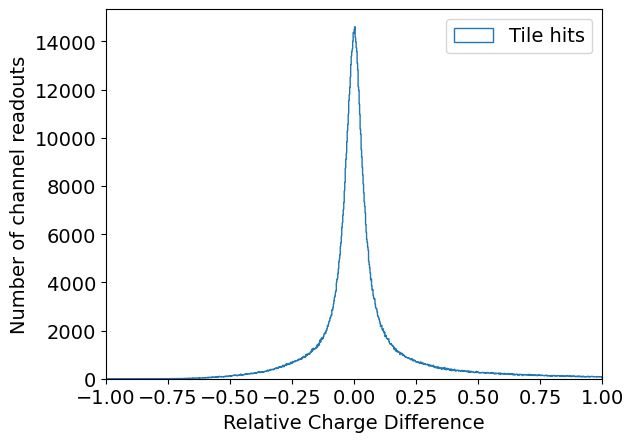

In [23]:
fig, ax = plt.subplots()

tBins = np.linspace(-1, 1, 1001)
fonts = 14

ax.hist(dT['fit_rel_diff'], bins = tBins, histtype = 'step', label = 'Tile hits')
# ax.set_yscale('log')
ax.set_xlim([-1, 1])

ax.set_xlabel('Relative Charge Difference', fontsize = fonts)
ax.set_ylabel('Number of channel readouts', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(fontsize = fonts)

In [31]:
dT['fit_pull'] = (dT['fit_charge']-0.5*dT['charge'])/err_sum
dT['fit_pull'].min(), dT['fit_pull'].max()

(-461.35644551598176, 2036.9160983055997)

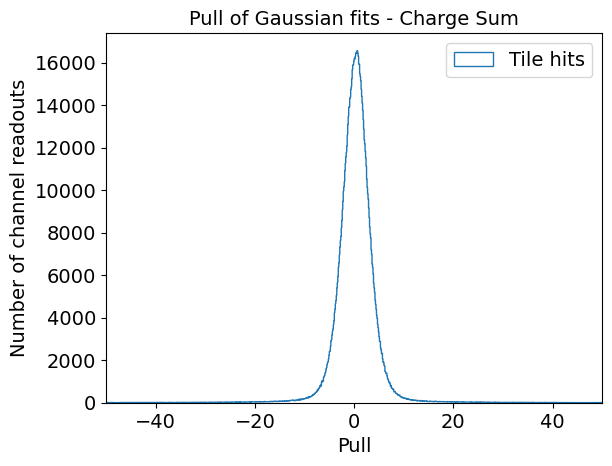

In [37]:
fig, ax = plt.subplots()

tBins = np.linspace(-50, 50, 1001)
fonts = 14

ax.hist(dT['fit_pull'], bins = tBins, histtype = 'step', label = 'Tile hits')
# ax.set_yscale('log')
ax.set_xlim([-50, 50])

ax.set_title('Pull of Gaussian fits - Charge Sum', fontsize = fonts)
ax.set_xlabel('Pull', fontsize = fonts)
ax.set_ylabel('Number of channel readouts', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(fontsize = fonts)

### Fit the pull distribution

In [43]:
from scipy.optimize import curve_fit

In [48]:
fit_pull = dT['fit_pull'].dropna().to_numpy()
counts, edges = np.histogram(fit_pull, bins = 2000, range = (-50, 50))
centers = 0.5 * (edges[:-1] + edges[1:])
# Initial guesses
p0 = [counts.max(), np.mean(fit_pull), np.std(fit_pull)]

# Fit Gaussian to histogram counts
params, covariance = curve_fit(gauss_no_offset, centers, counts, p0 = p0)
pull_A, pull_mu, pull_sigma = params
pull_A, pull_mu, pull_sigma

(np.float64(7982.83292274728),
 np.float64(0.3222981055040005),
 np.float64(2.5853258969235493))

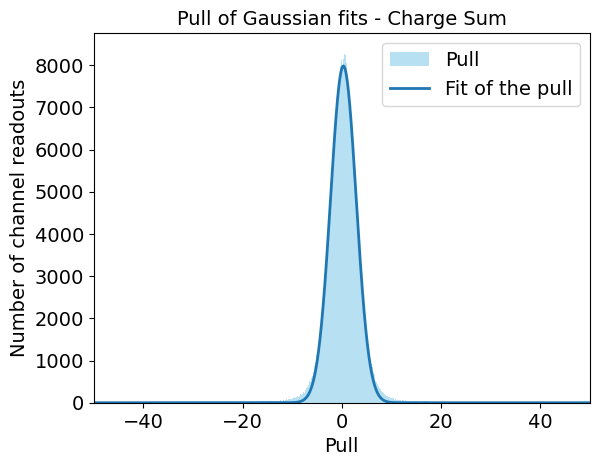

In [49]:
fig, ax = plt.subplots()

pBins = np.linspace(-50, 50, 2001)
fonts = 14

ax.hist(dT['fit_pull'], bins = pBins, alpha = 0.6, color = "skyblue", label = 'Pull')
ax.plot(pBins, gauss_no_offset(pBins, pull_A, pull_mu, pull_sigma), lw = 2, label = 'Fit of the pull')

# ax.set_yscale('log')
ax.set_xlim([-50, 50])

ax.set_title('Pull of Gaussian fits - Charge Sum', fontsize = fonts)
ax.set_xlabel('Pull', fontsize = fonts)
ax.set_ylabel('Number of channel readouts', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(fontsize = fonts)